<a href="https://colab.research.google.com/github/maulikcmr05/Deep-Learning/blob/main/E3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile
import urllib.request
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from tensorflow.keras import layers, Sequential
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Step 2: Load the 20 Newsgroups dataset
categories = [
"alt.atheism",
"comp.graphics",
"sci.space",
"rec.sport.baseball"
]
train_data = fetch_20newsgroups(
subset="train",
categories=categories,
remove=("headers", "footers", "quotes")
)
test_data = fetch_20newsgroups(
subset="test",
categories=categories,
remove=("headers", "footers", "quotes")
)
print("Training samples:", len(train_data.data))
print("Test samples:", len(test_data.data))
print("Classes:", train_data.target_names)

Training samples: 2254
Test samples: 1499
Classes: ['alt.atheism', 'comp.graphics', 'rec.sport.baseball', 'sci.space']


In [3]:
# Step 3: Convert text into integer sequences
MAX_WORDS = 10000
MAX_LEN = 200
vectorizer = layers.TextVectorization(
max_tokens=MAX_WORDS,
output_mode="int",
output_sequence_length=MAX_LEN
)
vectorizer.adapt(
tf.data.Dataset.from_tensor_slices(train_data.data).batch(64)
)
X_train = vectorizer(np.array(train_data.data))
X_test = vectorizer(np.array(test_data.data))
y_train = np.array(train_data.target)
y_test = np.array(test_data.target)
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (2254, 200)
X_test shape : (1499, 200)


In [5]:
# Step 4: Download and load pre-trained GloVe embeddings
glove_txt = "/content/glove.6B.100d.txt"
glove_zip = "/content/glove.6B.zip"
if not os.path.exists(glove_txt):
  print("Downloading GloVe embeddings...")
  urllib.request.urlretrieve(
  "https://nlp.stanford.edu/data/glove.6B.zip",
  glove_zip
  )
  with zipfile.ZipFile(glove_zip) as z:
    z.extract("glove.6B.100d.txt", "/content")
embedding_index = {}
with open(glove_txt, encoding="utf-8") as f:
  for line in f:
    values = line.rstrip().split(" ")
    word = values[0]
    vector = np.asarray(values[1:], dtype="float32")
    if len(vector) == 100:
      embedding_index[word] = vector
vocabulary = vectorizer.get_vocabulary()
embedding_matrix = np.zeros((len(vocabulary), 100), dtype="float32")
for i, word in enumerate(vocabulary):
  vector = embedding_index.get(word)
  if vector is not None:
    embedding_matrix[i] = vector
print("Vocabulary size:", len(vocabulary))
print("Embedding matrix shape:", embedding_matrix.shape)

Vocabulary size: 10000
Embedding matrix shape: (10000, 100)


In [6]:
# Step 5: Build and compile the text-classification model
model_text = Sequential([
layers.Input(shape=(MAX_LEN,)),
layers.Embedding(
input_dim=len(vocabulary),
output_dim=100,
weights=[embedding_matrix],
trainable=False,
name="pretrained_glove"
),
layers.GlobalAveragePooling1D(),
layers.Dense(len(categories), activation="softmax", name="softmax_output")
])
model_text.compile(
optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)
model_text.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_glove (Embedding)    │ (None, 200, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,404 (3.82 MB)

 Trainable params: 404 (1.58 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [7]:
# Step 6: Train the model
history_text = model_text.fit(
X_train,
y_train,
epochs=8,
batch_size=64,
validation_split=0.1,
verbose=1
)

Epoch 1/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3945 - loss: 1.3779 - val_accuracy: 0.5133 - val_loss: 1.3461
Epoch 2/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4635 - loss: 1.3396 - val_accuracy: 0.4602 - val_loss: 1.3231
Epoch 3/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4719 - loss: 1.3174 - val_accuracy: 0.5442 - val_loss: 1.3001
Epoch 4/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5922 - loss: 1.2969 - val_accuracy: 0.6637 - val_loss: 1.2788
Epoch 5/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6386 - loss: 1.2772 - val_accuracy: 0.6858 - val_loss: 1.2607
Epoch 6/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6632 - loss: 1.2581 - val_accuracy: 0.6903 - val_loss: 1.2402
Epoch 7/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6829 - loss: 1.2404 - val_accuracy: 0.6947 - val_loss: 1.2231
Epoch 8/8
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6874 - loss: 1.2228 - val_accuracy: 0.7080 - val_loss: 1.2060

In [8]:
# Step 7: Evaluate the model
test_loss, test_accuracy = model_text.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 1.2165
Test Accuracy: 0.6811


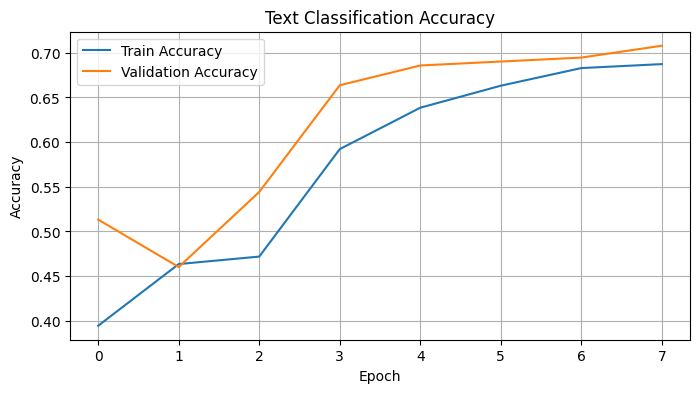

In [9]:
# Step 8: Plot training and validation accuracy
plt.figure(figsize=(8, 4))
plt.plot(history_text.history["accuracy"], label="Train Accuracy")
plt.plot(history_text.history["val_accuracy"], label="Validation Accuracy")
plt.title("Text Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()